In [30]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:

data_path = "Student_performance_data _.csv"
df = pd.read_csv(data_path)
print(df.columns.tolist())

['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [32]:
print(df.head())
print(df.shape)
print(df.columns.tolist())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [33]:
print(df.info())
print(df.isnull().sum())
print(df["GradeClass"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None
StudentID          

In [34]:
target_col = "GradeClass"
drop_cols = ["StudentID"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (2392, 13)
y shape: (2392,)
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  
0  2.929196  
1  3.042915  
2

In [35]:
#label encoder turns target into a number(if it isnt alr)
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

print("Target classes:", label_enc.classes_)
print("Encoded sample:", y_encoded[:10])

Target classes: [0. 1. 2. 3. 4.]
Encoded sample: [2 1 4 3 4 1 2 4 2 0]


In [36]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1913, 13)
Test shape: (479, 13)


In [37]:
#preprocessing
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Categorical features: []


In [38]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [39]:
#building pipeline for KNN
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", KNeighborsClassifier())
])

In [42]:
#feature selection (vlera e k 3,5,7,10..)

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", KNeighborsClassifier())
])

param_grid = {
    "feature_selection__k": [3, 5, 7, 10, "all"],
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}


grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

[CV] END classifier__metric=manhattan, classifier__n_neighbors=9, classifier__weights=uniform, feature_selection__k=all; total time=   0.1s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=9, classifier__weights=uniform, feature_selection__k=all; total time=   0.1s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=9, classifier__weights=uniform, feature_selection__k=all; total time=   0.1s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=9, classifier__weights=uniform, feature_selection__k=all; total time=   0.1s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=11, classifier__weights=uniform, feature_selection__k=5; total time=   0.0s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=11, classifier__weights=uniform, feature_selection__k=5; total time=   0.0s
[CV] END classifier__metric=manhattan, classifier__n_neighbors=11, classifier__weights=uniform, fe

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__metric': ['euclidean', 'manhattan'], 'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance'], 'feature_selection__k': [3, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Macro:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'feature_selection__k': 3}

Best Cross-Validation F1 Macro:
0.8209382591601434


In [25]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [44]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")

Test Metrics:
Accuracy: 0.8476
Precision (macro): 0.8176
Recall (macro): 0.7409
F1-score (macro): 0.7540


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_enc.classes_]))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.33      0.48        21
         1.0       0.75      0.78      0.76        54
         2.0       0.77      0.88      0.82        78
         3.0       0.77      0.80      0.78        83
         4.0       0.93      0.91      0.92       243

    accuracy                           0.85       479
   macro avg       0.82      0.74      0.75       479
weighted avg       0.85      0.85      0.84       479



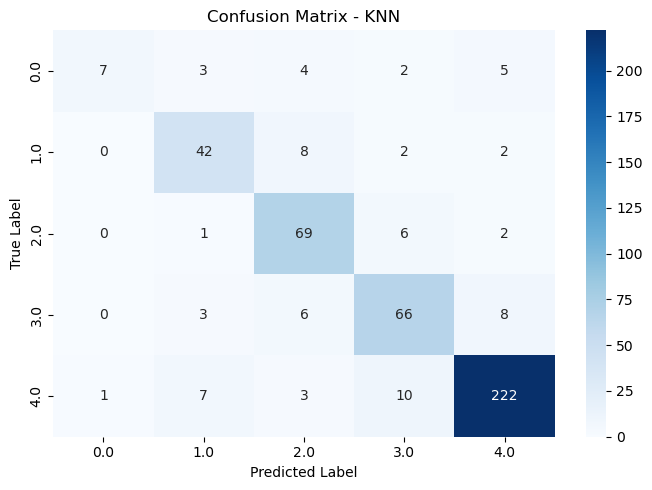

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_enc.classes_,
    yticklabels=label_enc.classes_
)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

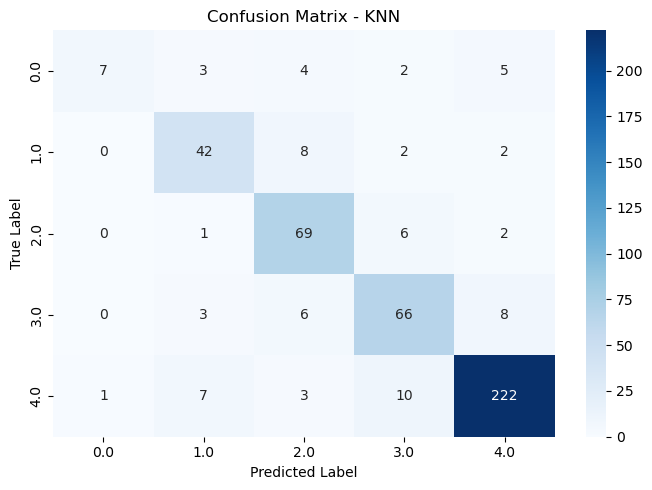

In [43]:
import os

os.makedirs("visualizations", exist_ok=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_enc.classes_,
    yticklabels=label_enc.classes_
)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("visualizations/knn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
results_df = pd.DataFrame({
    "Model": ["KNN"],
    "Best_Params": [str(grid_search.best_params_)],
    "CV_F1_Macro": [grid_search.best_score_],
    "Test_Accuracy": [accuracy],
    "Test_Precision_Macro": [precision],
    "Test_Recall_Macro": [recall],
    "Test_F1_Macro": [f1]
})

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/knn_results.csv", index=False)

print("Results saved to results/knn_results.csv")

Results saved to results/knn_results.csv
